# 3.1. Statistics in Python
The following notebook demonstrates how Python is useful in statistical analysis in various ways.

## 3.1.1. Data representation and interaction
This section looks at what ways data can be displayed. Subsequently, it will demonstrate ways in which this data can be manipulated.

### 3.1.1.1. Data as a table and 3.1.1.2. The pandas data-frame
This allows for a proper statistical analysis using a given csv file. Additionally, this gives several visual representations of various rows and columns that compile a dataset. Using pandas.DataFrame gives way to this. Note the resulting scatter matrix visuals at the end of this section. The two sub-populations do not correspond to gender since bimodal distribution remains in both males and females.

In [1]:
# Download brain_size.csv, import pandas, read csv file, and view in table
import pandas
data = pandas.read_csv('brain_size.csv', sep=';', na_values=".")
data

,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545
5,6,Female,99,90,110,146.0,69.0,928799
6,7,Female,138,136,131,138.0,64.5,991305
7,8,Female,92,90,98,175.0,66.0,854258
8,9,Male,89,93,84,134.0,66.3,904858
9,10,Male,133,114,147,172.0,68.8,955466


In [2]:
# Import numpy and create arrays
import numpy as np
t = np.linspace(-6, 6, 20)
sin_t = np.sin(t)
cos_t = np.cos(t)

In [3]:
# Use pandas.DataFrame to be able to expose them
pandas.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})

,t,sin,cos
0,-6.000000,0.279415,0.960170
1,-5.368421,0.792419,0.609977
2,-4.736842,0.999701,0.024451
3,-4.105263,0.821291,-0.570509
4,-3.473684,0.326021,-0.945363
5,-2.842105,-0.295030,-0.955488
6,-2.210526,-0.802257,-0.596979
7,-1.578947,-0.999967,-0.008151
8,-0.947368,-0.811882,0.583822
9,-0.315789,-0.310567,0.950551


In [4]:
data.shape # 40 rows and 8 columns

(40, 8)

In [5]:
data.columns # It has columns

Index(['Unnamed: 0', 'Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height',
       'MRI_Count'],
      dtype='object')

In [6]:
print(data['Gender']) # Columns can be addressed by name

0     Female
1       Male
2       Male
3       Male
4     Female
5     Female
6     Female
7     Female
8       Male
9       Male
10    Female
11      Male
12      Male
13    Female
14    Female
15    Female
16    Female
17      Male
18    Female
19      Male
20      Male
21      Male
22    Female
23      Male
24    Female
25      Male
26    Female
27      Male
28    Female
29    Female
30    Female
31      Male
32      Male
33      Male
34    Female
35    Female
36      Male
37    Female
38      Male
39      Male
Name: Gender, dtype: object


In [7]:
# Simpler selector
print(data[data['Gender'] == 'Female']['VIQ'].mean())

109.45


In [8]:
# Use groupby to split dataframe
groupby_gender = data.groupby('Gender')
for gender, value in groupby_gender['VIQ']:
    print((gender, float(value.mean())))

('Female', 109.45)
('Male', 115.25)


In [9]:
# Expose operations
groupby_gender.mean()

,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,,
Female,19.65,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,21.35,115.0,115.25,111.60,166.444444,71.431579,954855.4


In [10]:
print(data['VIQ'].mean()) # Mean VIQ for full population

112.35


In [11]:
groupby_gender.count() # Males/Females included in study

,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,,
Female,20,20,20,20,20,20,20
Male,20,20,20,20,18,19,20


In [12]:
# Average value of MRI counts for males and females using log units
data['log_MRI'] = np.log(data['MRI_Count'])
print(data.groupby('Gender')[['log_MRI']].mean())

          log_MRI
Gender           
Female  13.665830
Male    13.767731


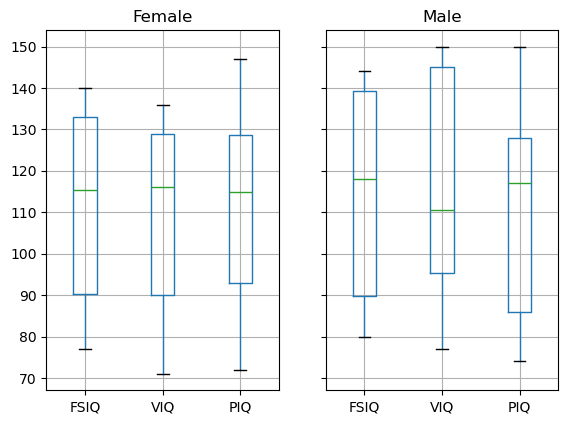

In [13]:
# Box plots of different columns for each gender
import matplotlib.pyplot as plt
groupby_gender = data.groupby('Gender')
groupby_gender.boxplot(column=['FSIQ', 'VIQ', 'PIQ'])
plt.show()

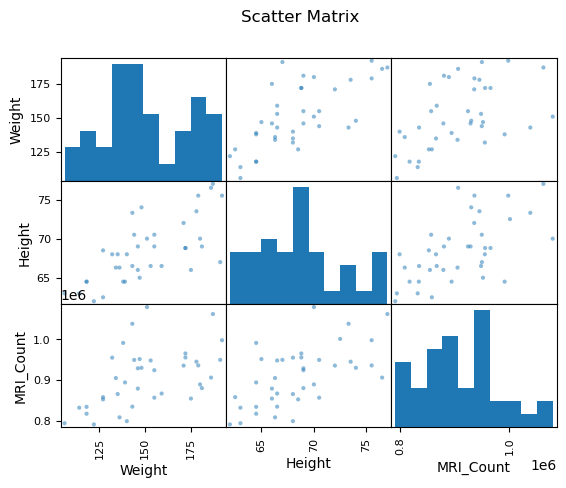

In [14]:
# Import plotting to plot scatter matrix
from pandas import plotting
plotting.scatter_matrix(data[['Weight', 'Height', 'MRI_Count']])
plt.suptitle('Scatter Matrix') # Insert title
plt.show()

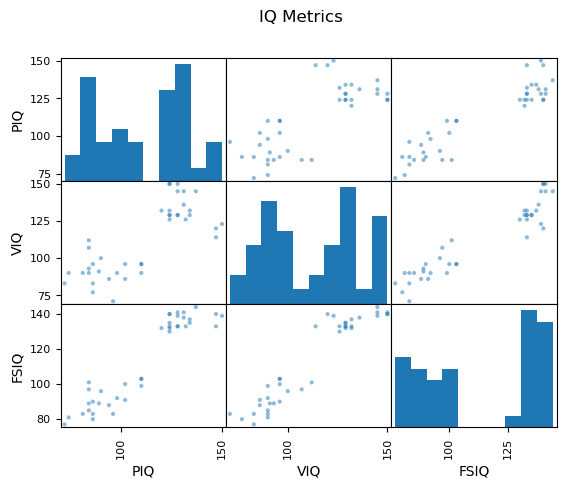

In [15]:
# Plot scatter PIQ, VIQ, FSIQ
plotting.scatter_matrix(data[['PIQ', 'VIQ', 'FSIQ']]) # IQ is bimodal
plt.suptitle('IQ Metrics')
plt.show()

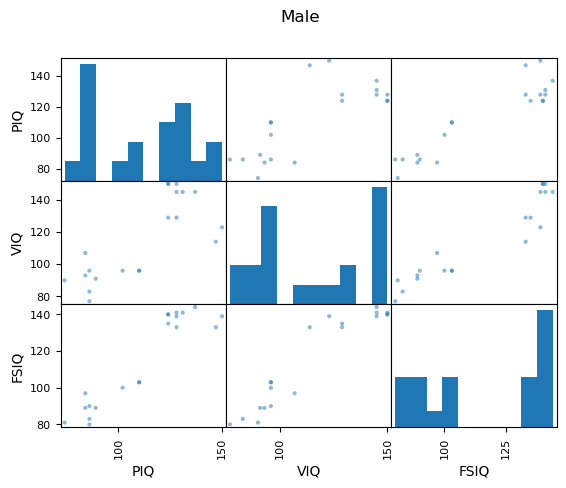

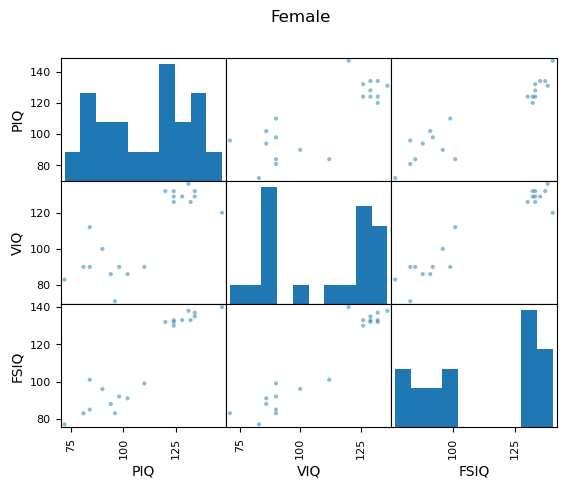

In [16]:
# Plot scatter matrix for only males and then only females
plotting.scatter_matrix(data[data['Gender'] == 'Male'][['PIQ', 'VIQ', 'FSIQ']])
plt.suptitle('Male')
plotting.scatter_matrix(data[data['Gender'] == 'Female'][['PIQ', 'VIQ', 'FSIQ']])
plt.suptitle('Female')
plt.show()

## 3.1.2. Hypothesis testing: comparing two groups
The following section begins with scipy for simple statistical tests. By the end, take note of the lack of evidence for differences in VIQ based on gender.

In [17]:
# Import scipy
from scipy import stats
np.set_printoptions(legacy="1.25")

### 3.1.2.1. Student’s t-test: the simplest statistical test
Sample t-tests can be done for a single population or across populations. The single population mean of data can be assessed against a given value with a 1-sample t-test. Across populations, a 2-sample t-test can demonstrate their differences.

In [18]:
# Perform sample t-test
stats.ttest_1samp(data['VIQ'], 0)

TtestResult(statistic=30.08809997084933, pvalue=1.3289196468727879e-28, df=39)

In [19]:
# Perform 2-sample t-test
female_viq = data[data['Gender'] == 'Female']['VIQ']
male_viq = data[data['Gender'] == 'Male']['VIQ']
stats.ttest_ind(female_viq, male_viq)

TtestResult(statistic=-0.7726161723275012, pvalue=0.44452876778583217, df=38.0)

### 3.1.2.2. Paired tests: repeated measurements on the same individuals
Here, paired tests can account for the inter-subject variability. It is important to note that this variance is confounding otherwise.

In [20]:
# Testing potential IQ differences
stats.ttest_ind(data['FSIQ'], data['PIQ'])

TtestResult(statistic=0.465637596380964, pvalue=0.6427725009414841, df=78.0)

In [21]:
# Repeated measures test
stats.ttest_rel(data['FSIQ'], data['PIQ'])

TtestResult(statistic=1.7842019405859857, pvalue=0.08217263818364236, df=39)

In [22]:
# 1-sample test equivalent
stats.ttest_1samp(data['FSIQ'] - data['PIQ'], 0)

TtestResult(statistic=1.7842019405859857, pvalue=0.08217263818364236, df=39)

In [23]:
# Wilcoxon signed-rank test
stats.wilcoxon(data['FSIQ'], data['PIQ'])

WilcoxonResult(statistic=274.5, pvalue=0.10659492713506856)

In [24]:
# Weight differences between males and females
female_weight = data[data['Gender'] == 'Female']['Weight']
male_weight = data[data['Gender'] == 'Male']['Weight']
stats.ttest_ind(female_viq, male_viq)

TtestResult(statistic=-0.7726161723275012, pvalue=0.44452876778583217, df=38.0)

In [25]:
# VIQ differences using non parametric statistics in males and females
female_viq = data[data['Gender'] == 'Female']['VIQ']
male_viq = data[data['Gender'] == 'Male']['VIQ']
stats.mannwhitneyu(female_viq, male_viq)

MannwhitneyuResult(statistic=164.5, pvalue=0.3422886868727315)

## 3.1.3. Linear models, multiple factors, and analysis of variance
This section uses linear models alongside their functions.

### 3.1.3.1. “formulas” to specify statistical models in Python
Here, a simple linear regression and categorical variables are studied. An equation y = x * coef + intercept + e is used for the hypothesis of y being a linear function of x. Note that e represents observation noise.

In [26]:
# y = x * coef + intercept + e
# Simulated data creation
import numpy as np
x = np.linspace(-5, 5, 20)
np.random.seed(1)
# normal distributed noise
y = -5 + 3*x + 4 * np.random.normal(size=x.shape)
# Create a data frame containing all the relevant variables
data = pandas.DataFrame({'x': x, 'y': y})

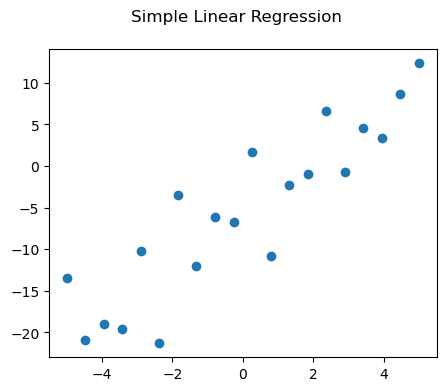

In [27]:
# Plot the data
plt.figure(figsize=(5, 4))
plt.plot(x, y, 'o')
plt.suptitle('Simple Linear Regression')
plt.show()

In [28]:
# Fit OLS model
from statsmodels.formula.api import ols
model = ols("y ~ x", data).fit()

In [29]:
# Studying the statistics garnered
print(model.summary())  

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           8.56e-08
Time:                        00:10:30   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5335      1.036     -5.342      0.0

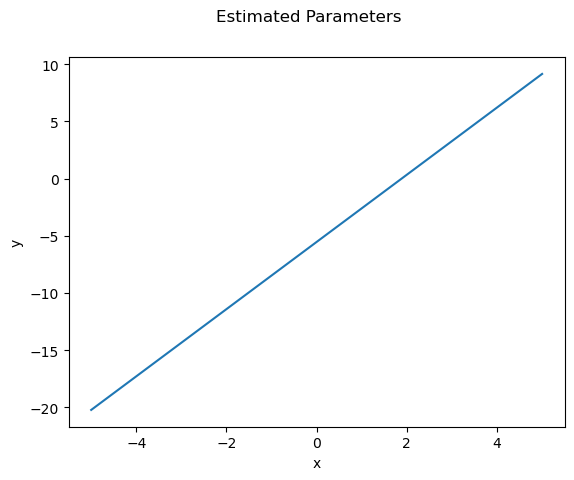

In [30]:
# Obtain the model's estimated parameters
offset, coef = model._results.params
plt.plot(x, x*coef + offset)
plt.xlabel('x')
plt.ylabel('y')
plt.suptitle('Estimated Parameters')
plt.show()

In [31]:
# Returning to brain_size.csv
data = pandas.read_csv('brain_size.csv', sep=';', na_values=".")

In [32]:
# Demonstrating categorical variables using IQ and gender
model = ols("VIQ ~ Gender + 1", data).fit()
print(model.summary())  

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.445
Time:                        00:10:30   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.

In [33]:
# Forcing categorical
model = ols('VIQ ~ C(Gender)', data).fit()

In [34]:
# Long-form table
data_fisq = pandas.DataFrame({'iq': data['FSIQ'], 'type': 'fsiq'})
data_piq = pandas.DataFrame({'iq': data['PIQ'], 'type': 'piq'})
data_long = pandas.concat((data_fisq, data_piq))
print(data_long)  

     iq  type
0   133  fsiq
1   140  fsiq
2   139  fsiq
3   133  fsiq
4   137  fsiq
..  ...   ...
35  128   piq
36  124   piq
37   94   piq
38   74   piq
39   89   piq

[80 rows x 2 columns]


In [35]:
# T-test and respective p-values
stats.ttest_ind(data['FSIQ'], data['PIQ'])  

TtestResult(statistic=0.465637596380964, pvalue=0.6427725009414841, df=78.0)

### 3.1.3.2. Multiple Regression: including multiple factors
Multiple regression is useful when there are two variables with a dependent variable being explained. An equation z = xc1 + yc2 + i + e in this case demonstrates the three variables x, y, and z. The variable Z is the dependent variable. In addition, iris.csv is used for a visual and ANOVA.

In [36]:
# z = xc1 + yc2 + i + e and iris.csv
data = pandas.read_csv('iris.csv')
model = ols('sepal_width ~ name + petal_length', data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        00:10:30   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0

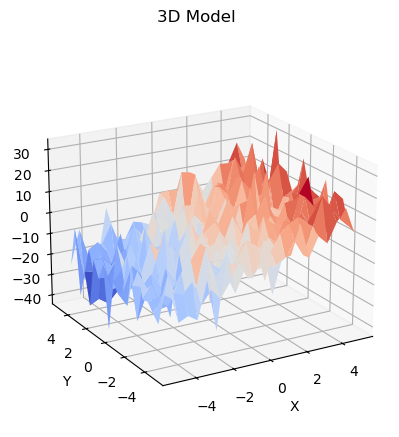

In [37]:
# 3D model
from mpl_toolkits.mplot3d import Axes3D
x = np.linspace(-5, 5, 21)
# We generate a 2D grid
X, Y = np.meshgrid(x, x)
# To get reproducable values, provide a seed value
np.random.seed(1)
# Z is the elevation of this 3D grid
Z = -5 + 3*X - 0.5*Y + 8 * np.random.normal(size=X.shape)
# Plot the data
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=plt.cm.coolwarm,
                       rstride=1, cstride=1)
ax.view_init(20, -120)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.suptitle('3D Model')
plt.show()

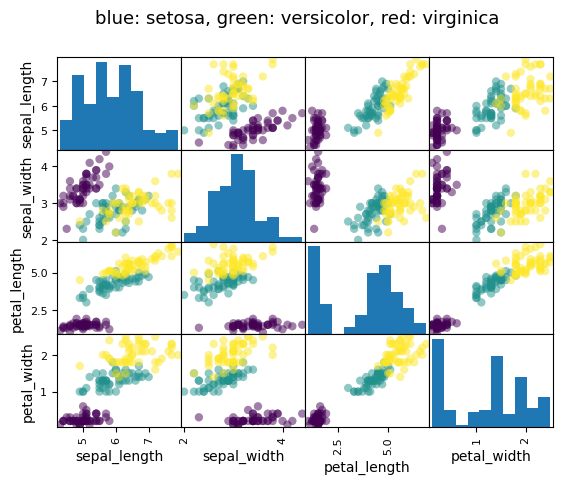

In [38]:
# Plot scatter matrix
# Express the names as categories
categories = pandas.Categorical(data['name'])
# The parameter 'c' is passed to plt.scatter and will control the color
plotting.scatter_matrix(data, c=categories.codes, marker='o')
fig = plt.gcf()
fig.suptitle("blue: setosa, green: versicolor, red: virginica", size=13)
plt.show() # Note systematic effect of species 

### 3.1.3.3. Post-hoc hypothesis testing: analysis of variance (ANOVA)
ANOVA is valuable when utilizing multiple categorical variables. This can be done by coefficient differences being tested in a linear model.

In [39]:
# ANOVA with F-test for iris.csv
print(model.f_test([0, 1, -1, 0])) # Note the resulting difference is not significant.

<F test: F=3.2453353465743553, p=0.07369058781700252, df_denom=146, df_num=1>


In [40]:
# Return to brain_size.csv
data = pandas.read_csv('brain_size.csv', sep=';', na_values=".")
model = ols("VIQ ~ Gender + MRI_Count + Height + Weight", data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     2.733
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0455
Time:                        00:10:31   Log-Likelihood:                -167.03
No. Observations:                  38   AIC:                             344.1
Df Residuals:                      33   BIC:                             352.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        169.7719     90.054      1.

## 3.1.4. More visualization: seaborn for statistical exploration
This section uses seaborn. It allows for plotting on pandas dataframes to be combined with simple statistical fits. The txt file wages.txt is utilized in this section.

In [41]:
# Import urllib.request and os
import urllib.request
import os

In [42]:
if not os.path.exists('wages.txt'):
    # Download the file if it is not present
    urllib.request.urlretrieve('http://lib.stat.cmu.edu/datasets/CPS_85_Wages',
                       'wages.txt')
# Give names to the columns
names = [
    'EDUCATION: Number of years of education',
    'SOUTH: 1=Person lives in South, 0=Person lives elsewhere',
    'SEX: 1=Female, 0=Male',
    'EXPERIENCE: Number of years of work experience',
    'UNION: 1=Union member, 0=Not union member',
    'WAGE: Wage (dollars per hour)',
    'AGE: years',
    'RACE: 1=Other, 2=Hispanic, 3=White',
    'OCCUPATION: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other',
    'SECTOR: 0=Other, 1=Manufacturing, 2=Construction',
    'MARR: 0=Unmarried,  1=Married',
]
short_names = [n.split(':')[0] for n in names]
data = pandas.read_csv('wages.txt', skiprows=27, skipfooter=6, sep=None,
                       header=None, engine='python')
data.columns = short_names
# Log-transform the wages, because they typically are increased with
# multiplicative factors
data['WAGE'] = np.log10(data['WAGE'])
print(data)

     EDUCATION  SOUTH  SEX  EXPERIENCE  UNION      WAGE  AGE  RACE  \
0            8      0    1          21      0  0.707570   35     2   
1            9      0    1          42      0  0.694605   57     3   
2           12      0    0           1      0  0.824126   19     3   
3           12      0    0           4      0  0.602060   22     3   
4           12      0    0          17      0  0.875061   35     3   
..         ...    ...  ...         ...    ...       ...  ...   ...   
529         18      0    0           5      0  1.055378   29     3   
530         12      0    1          33      0  0.785330   51     1   
531         17      0    1          25      1  1.366423   48     1   
532         12      1    0          13      1  1.298416   31     3   
533         16      0    0          33      0  1.186956   55     3   

     OCCUPATION  SECTOR  MARR  
0             6       1     1  
1             6       1     1  
2             6       1     0  
3             6       0     0  

### 3.1.4.1. Pairplot: scatter matrices
Here, a pairplot in seaborn is used to show a scatter matrix using the aforementioned txt file. Continuous variables and their interactions can be noted as well as a respective intuition from this.

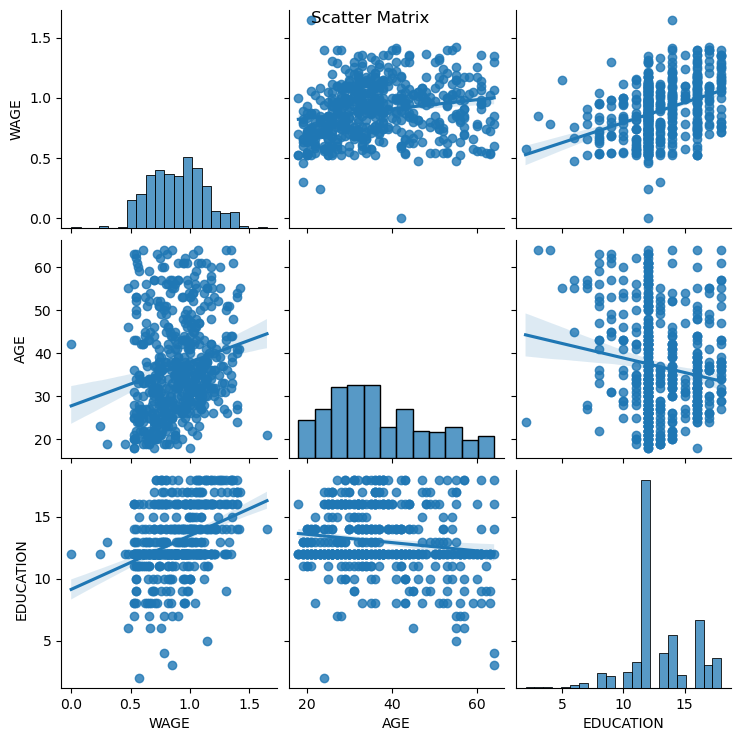

In [43]:
# Pairplot
import seaborn
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg')
plt.suptitle('Scatter Matrix')
plt.show()

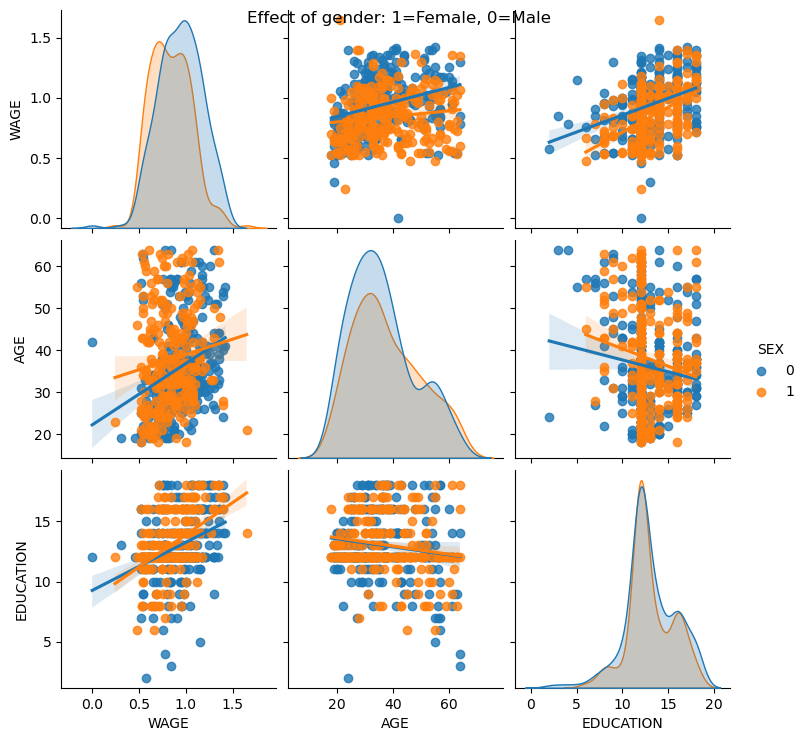

In [44]:
# Categorical variables and plotting them as the hue
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg', hue='SEX')
plt.suptitle('Effect of gender: 1=Female, 0=Male')
plt.show()

### 3.1.4.2. lmplot: plotting a univariate regression
The following shows how a lmplot is done with seaborn. With this, the relationship of variables is displayed by a regression. A robust regression can also be noted.

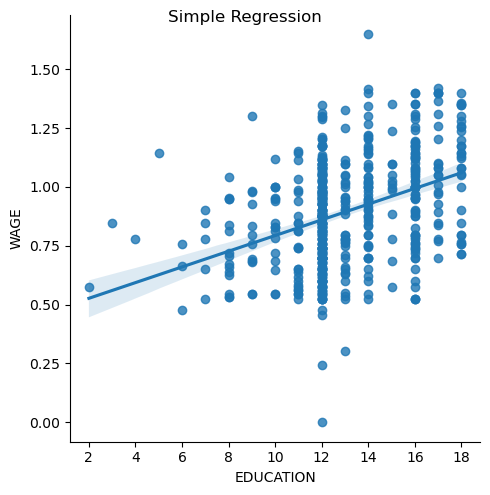

In [45]:
# Use lmplot
seaborn.lmplot(y='WAGE', x='EDUCATION', data=data)
plt.suptitle('Simple Regression')
plt.show()

## 3.1.5. Testing for interactions
This section continues to use wages.txt. Here, an interaction is demonstrated to assess slope variance across females and males as populations. Note it cannot be said that education is more impactful for males than females, nor that an increase in education increases wages more in males than females.

In [46]:
if not os.path.exists('wages.txt'):
    # Download the file if it is not present
    urllib.request.urlretrieve('http://lib.stat.cmu.edu/datasets/CPS_85_Wages',
                       'wages.txt')
# Give names to the columns
names = [
    'EDUCATION: Number of years of education',
    'SOUTH: 1=Person lives in South, 0=Person lives elsewhere',
    'SEX: 1=Female, 0=Male',
    'EXPERIENCE: Number of years of work experience',
    'UNION: 1=Union member, 0=Not union member',
    'WAGE: Wage (dollars per hour)',
    'AGE: years',
    'RACE: 1=Other, 2=Hispanic, 3=White',
    'OCCUPATION: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other',
    'SECTOR: 0=Other, 1=Manufacturing, 2=Construction',
    'MARR: 0=Unmarried,  1=Married',
]
short_names = [n.split(':')[0] for n in names]
data = pandas.read_csv('wages.txt', skiprows=27, skipfooter=6, sep=None,
                       header=None, engine='python')
data.columns = short_names
import statsmodels.formula.api as sm

# Note that this model is not the plot displayed above: it is one
# joined model for male and female, not separate models for male and
# female. The reason is that a single model enables statistical testing
result = sm.ols(formula='WAGE ~ EDUCATION + SEX', data=data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     61.62
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           8.63e-25
Time:                        00:10:36   Log-Likelihood:                -1575.6
No. Observations:                 534   AIC:                             3157.
Df Residuals:                     531   BIC:                             3170.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2178      1.036      0.210      0.8

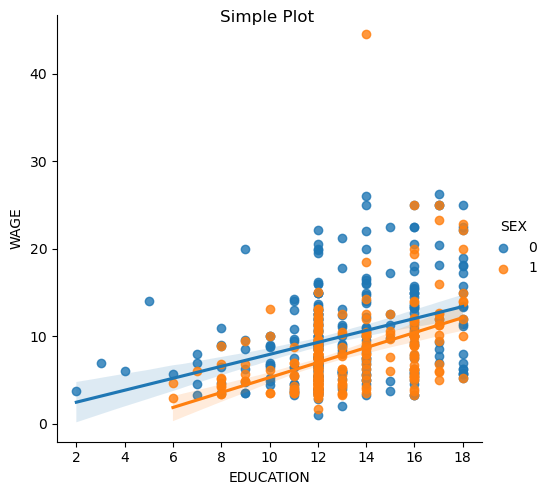

In [47]:
import seaborn
# Plot 2 linear fits for male and female.
seaborn.lmplot(y='WAGE', x='EDUCATION', hue='SEX', data=data)
plt.suptitle('Simple Plot')
plt.show()